# 49.3 · ONNX export and runtime parity

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain onnx export and runtime parity using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[24 · PyTorch for Computer Vision](../../24-pytorch-for-computer-vision/README.md), [27 · Object Detection](../../27-object-detection/README.md), [31 · Semantic Segmentation](../../31-semantic-segmentation/README.md), [37 · Vision Transformers](../../37-vision-transformers/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

Optimization changes runtime, memory or storage while controlling output quality. Faster arithmetic is useful only when it improves the actual bottleneck. Measure a representative workload before choosing quantization, pruning, compilation or a different architecture.

## 2. Intuition

ONNX is an interchange graph format; export success alone does not prove numerical equivalence or performance. The export script trains TinyCNN, checks its ONNX graph and compares CPU runtime logits on a held-out batch. TensorRT concepts include graph optimization, precision selection and engine compilation, which require compatible target hardware for validation.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 49
LESSON = 2
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
q=clip(round(w/s),-127,127),\quad\hat w=sq
$$

w is a weight, s a positive scale, q its signed int8 code and ŵ the reconstruction. With w=0.26 and s=0.1, q=3 and ŵ=0.3, giving error 0.04.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
weight, scale = 0.26, 0.1
quantized = np.clip(np.rint(weight / scale), -127, 127).astype(np.int8)
reconstructed = float(quantized) * scale
assert np.isclose(reconstructed, 0.3)
print(quantized, reconstructed)

3 0.30000000000000004


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

The local lab records storage and output error for a quantized weight matrix. scripts/export_model.py adds actual graph validation and ONNX Runtime output agreement.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def optimization(lesson=0, seed=42, amount=1.0):
    rng = np.random.default_rng(seed)
    weights = rng.normal(0, 0.1 * amount, (64, 128)).astype("float32")
    x = rng.normal(size=(16, 128)).astype("float32")
    q, scale, reconstructed = quantize_symmetric(weights)
    baseline = x @ weights.T
    approximation = x @ reconstructed.T
    timings = []
    for matrix in (weights, reconstructed):
        samples = []
        for _ in range(30):
            start = time.perf_counter()
            x @ matrix.T
            samples.append((time.perf_counter() - start) * 1e6)
        timings.append(float(np.median(samples)))
    return Result(
        "49 · Quantization error and fair measurement",
        {
            "Original weights": weights,
            "Reconstructed weights": reconstructed,
            "Output error": approximation - baseline,
        },
        metrics={
            "float_storage_bytes": weights.nbytes,
            "int8_storage_bytes_with_scale": q.nbytes + 4,
            "scale": scale,
            "output_rmse": float(np.sqrt(np.mean((baseline - approximation) ** 2))),
            "float_matmul_median_us": timings[0],
            "dequantized_matmul_median_us": timings[1],
        },
        notes="Both timings use float32 multiplication. Reduced storage alone does not imply int8 acceleration. Actual ONNX export/runtime comparison is available through scripts/export_model.py; TensorRT requires supported NVIDIA hardware.",
    )

{
  "float_storage_bytes": 32768,
  "int8_storage_bytes_with_scale": 8196,
  "scale": 0.003455995809374832,
  "output_rmse": 0.011276859790086746,
  "float_matmul_median_us": 5.162500201549847,
  "dequantized_matmul_median_us": 5.087500085210195
}
Both timings use float32 multiplication. Reduced storage alone does not imply int8 acceleration. Actual ONNX export/runtime comparison is available through scripts/export_model.py; TensorRT requires supported NVIDIA hardware.


## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/engineering.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.engineering import quantize_symmetric

display(Code(inspect.getsource(quantize_symmetric), language="python"))

def quantize_symmetric(weights):
    """Per-tensor signed int8 quantization and floating reconstruction."""
    scale = max(float(np.max(np.abs(weights))) / 127, np.finfo(float).eps)
    quantized = np.clip(np.rint(weights / scale), -127, 127).astype(np.int8)
    return quantized, scale, quantized.astype(np.float32) * scale

## 8. Experiment

Quantize a weight distribution with an outlier and compare per-tensor and per-channel error. Measure the target runtime rather than extrapolating from file size.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "float_storage_bytes": 32768,
    "int8_storage_bytes_with_scale": 8196,
    "scale": 0.003455995809374832,
    "output_rmse": 0.011276859790086746,
    "float_matmul_median_us": 5.162500201549847,
    "dequantized_matmul_median_us": 5.087500085210195
  },
  "second_seed": {
    "float_storage_bytes": 32768,
    "int8_storage_bytes_with_scale": 8196,
    "scale": 0.0028026800925337425,
    "output_rmse": 0.009215143509209156,
    "float_matmul_median_us": 5.2129998948657885,
    "dequantized_matmul_median_us": 5.3679998472944135
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

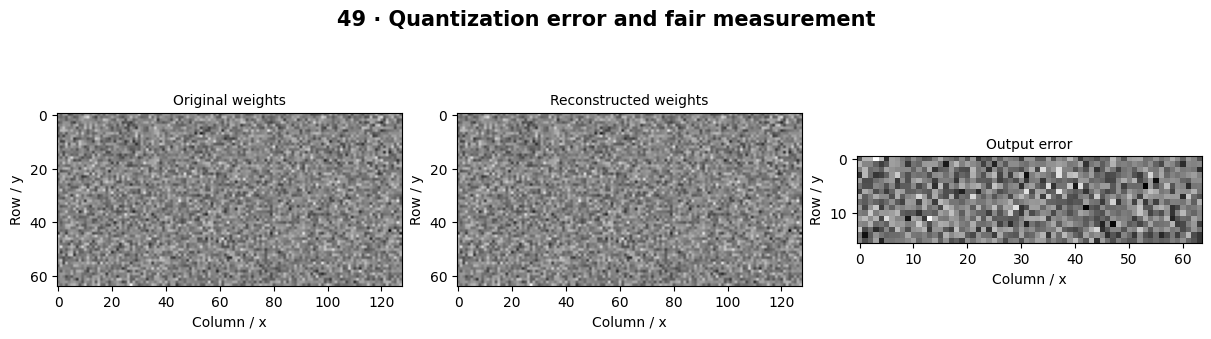

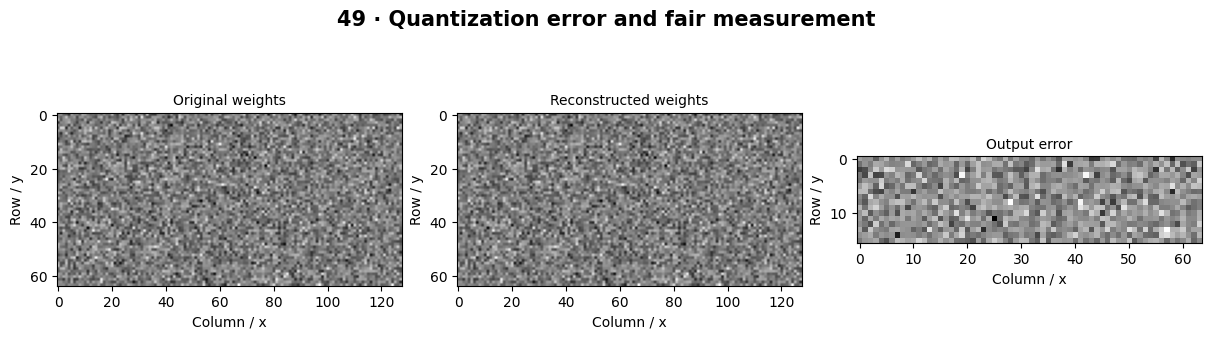

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Model Optimization Lab**. Benchmark speed, memory and accuracy on the same workload. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

Benchmarking a first call includes initialization. Numerically close logits can still cross a decision threshold on borderline examples.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Quantize a weight distribution with an outlier and compare per-tensor and per-channel error. Measure the target runtime rather than extrapolating from file size.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Optimize a trained vision model under a latency and quality budget, including preprocessing and end-to-end timing.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

ONNX is an interchange graph format; export success alone does not prove numerical equivalence or performance. The export script trains TinyCNN, checks its ONNX graph and compares CPU runtime logits on a held-out batch. TensorRT concepts include graph optimization, precision selection and engine compilation, which require compatible target hardware for validation.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

[50 · Computer Vision Deployment](../../50-computer-vision-deployment/README.md)

[Primary reference](https://docs.pytorch.org/docs/stable/onnx.html) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)